In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
df = pd.read_csv("creditcard.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [9]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [13]:
print("Class Distribution:")
print(df["Class"].value_counts())

print("\nClass Percentage:")
print((df["Class"].value_counts(normalize=True) * 100).round(4))

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


### Observation

The dataset is highly imbalanced. Out of 284,807 transactions, 284,315 (99.8273%) are legitimate, while only 492 (0.1727%) are fraudulent.

This severe class imbalance means that fraudulent transactions represent only a very small proportion of the dataset. Therefore, a machine learning model could achieve a high accuracy by predicting most transactions as legitimate while still failing to detect a significant number of fraudulent transactions.

Because of this imbalance, accuracy alone is not an appropriate metric for evaluating the fraud detection models. Precision, Recall, F1-Score, and AUC-ROC will be used as the primary evaluation metrics.

In [14]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

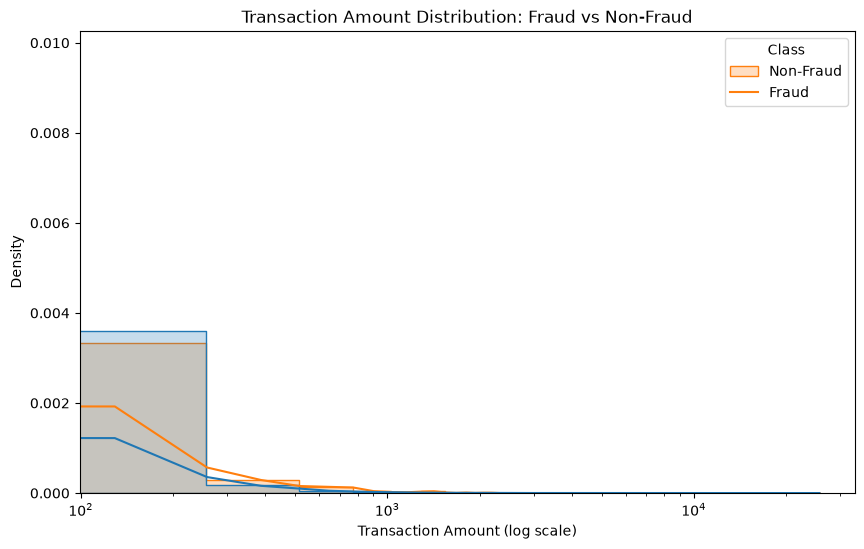

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.xscale("log")
plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Density")
plt.legend(title="Class", labels=["Non-Fraud", "Fraud"])
plt.show()

### Observation

The transaction amount distribution is highly right-skewed, with most transactions concentrated at relatively low amounts and a small number of transactions having very large values.

The distributions of fraudulent and non-fraudulent transactions overlap substantially, indicating that transaction amount alone may not be sufficient to distinguish fraudulent transactions from legitimate ones.

A logarithmic scale was used to make the distribution easier to visualize because the transaction amounts range from 0 to 25,691.16.

In [16]:
# Convert elapsed time into hour of day
df["Hour"] = ((df["Time"] % 86400) // 3600).astype(int)

# Check the result
df[["Time", "Hour", "Class"]].head()

,Time,Hour,Class
0,0.0,0,0
1,0.0,0,0
2,1.0,0,0
3,1.0,0,0
4,2.0,0,0


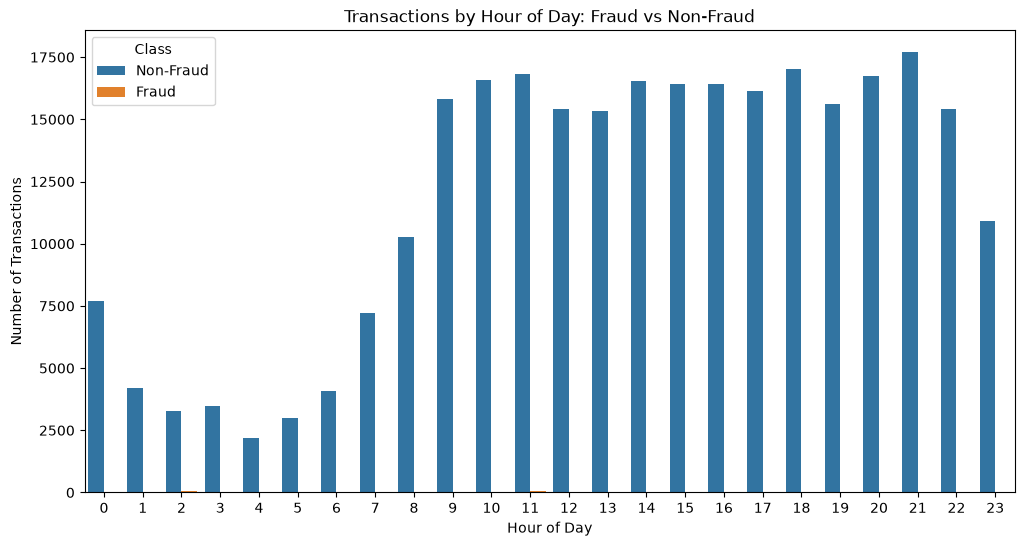

In [29]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Hour",
    hue="Class"
)

plt.title("Transactions by Hour of Day: Fraud vs Non-Fraud")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.legend(title="Class", labels=["Non-Fraud", "Fraud"])
plt.show()

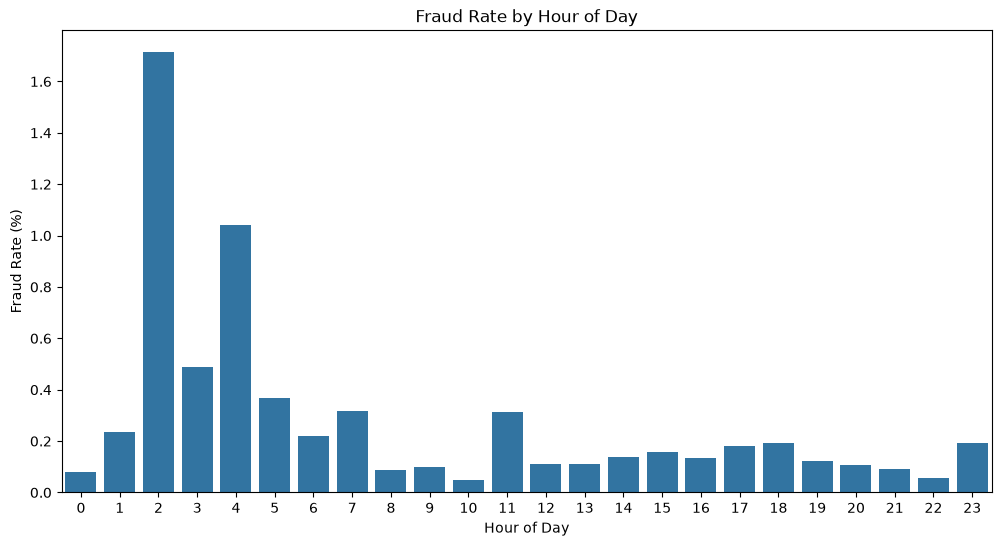

In [20]:
hour_fraud_rate = (
    df.groupby("Hour")["Class"]
    .mean()
    .mul(100)
    .reset_index(name="Fraud_Rate")
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=hour_fraud_rate,
    x="Hour",
    y="Fraud_Rate"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.show()

### Observation

The number of transactions varies across the hours of the day. Transaction activity is relatively lower during the early hours and increases substantially during the later morning and daytime hours.

Fraudulent transactions occur across different hours rather than being concentrated in a single period. However, because fraudulent transactions represent only 0.1727% of the entire dataset, their counts are much smaller than those of legitimate transactions.

This time-of-day analysis suggests that transaction timing may provide useful information for fraud detection, although it should be considered together with other transaction features.

### Why Standard Accuracy Is Misleading in Fraud Detection

Accuracy measures the proportion of all predictions that are correct. However, it can be misleading when working with a highly imbalanced dataset such as this fraud detection dataset.

In this dataset, 99.8273% of transactions are legitimate, while only 0.1727% are fraudulent. A model that predicts nearly every transaction as legitimate could achieve very high accuracy while failing to identify many fraudulent transactions.

For fraud detection, correctly identifying fraudulent transactions is particularly important. Therefore, accuracy alone does not provide enough information about how well the model detects the minority fraud class.

Instead, this project will focus on Precision, Recall, F1-Score, and AUC-ROC. These metrics provide more useful information about the model’s ability to identify fraudulent transactions and manage false-positive and false-negative predictions.

In [21]:
# Separate features and target variable

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 31)
Target shape: (284807,)


In [22]:
# Split the data into training and testing sets
# Stratification ensures both sets contain fraud cases in similar proportions

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (227845, 31)
X_test shape: (56962, 31)
y_train shape: (227845,)
y_test shape: (56962,)


In [23]:
# Check class distribution before applying SMOTE

print("Class distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass percentages before SMOTE:")
print((y_train.value_counts(normalize=True) * 100).round(4))

Class distribution before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Class percentages before SMOTE:
Class
0    99.8271
1     0.1729
Name: proportion, dtype: float64


In [24]:
# Apply SMOTE to the training data only

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

print("\nTraining data shape after SMOTE:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

Class distribution after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Training data shape after SMOTE:
X_train_smote: (454902, 31)
y_train_smote: (454902,)


### Handling Class Imbalance with SMOTE

The training data was highly imbalanced, with 227,451 legitimate transactions (99.8271%) and only 394 fraudulent transactions (0.1729%).

To address this imbalance, the Synthetic Minority Over-sampling Technique (SMOTE) was applied to the training data. SMOTE generates synthetic examples of the minority fraud class to increase its representation without simply duplicating existing observations.

After applying SMOTE, the training dataset contained 227,451 legitimate transactions and 227,451 fraudulent transactions, resulting in a balanced training set of 454,902 observations.

The test data was not oversampled and remains untouched so that model performance can be evaluated on data that reflects the original class distribution.

In [25]:
# Scale the features for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

Scaled training data shape: (454902, 31)
Scaled test data shape: (56962, 31)


In [26]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train_smote)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [27]:
# Train Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_smote, y_train_smote)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [28]:
# Generate predictions from both models

# Logistic Regression predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [30]:
# Calculate evaluation metrics for both models

# Logistic Regression metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))
print("AUC-ROC  :", round(logistic_auc, 4))

print("\nRandom Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("AUC-ROC  :", round(rf_auc, 4))

Logistic Regression
-------------------
Accuracy : 0.9895
Precision: 0.1306
Recall   : 0.898
F1-Score : 0.228
AUC-ROC  : 0.9766

Random Forest
-------------
Accuracy : 0.9994
Precision: 0.8351
Recall   : 0.8265
F1-Score : 0.8308
AUC-ROC  : 0.9636


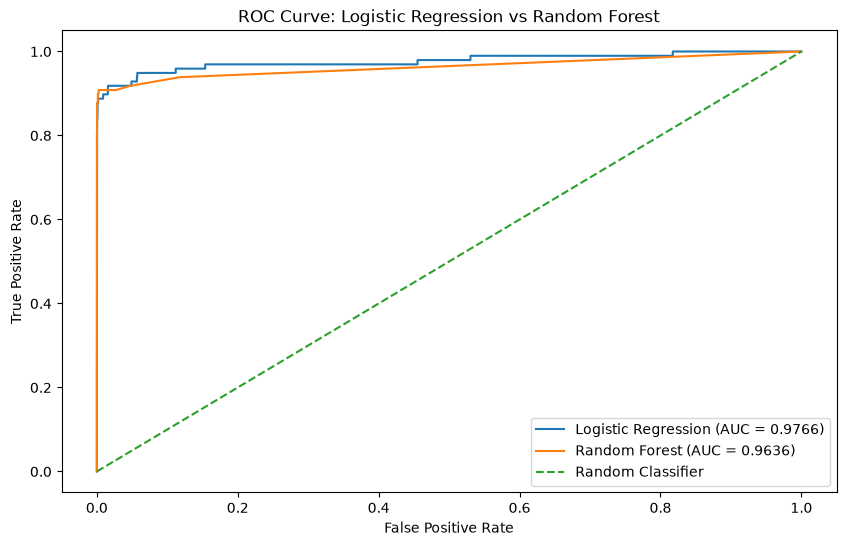

In [32]:
# Plot ROC curves for both models

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve: Logistic Regression vs Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Model Evaluation Results

The two models were evaluated using Accuracy, Precision, Recall, F1-Score, and AUC-ROC on the original, untouched test dataset.

### Observation

Both models achieved high accuracy, but the other evaluation metrics reveal important differences. Logistic Regression achieved a high Recall of 89.80%, meaning it identified a large proportion of the fraudulent transactions. However, its Precision was only 13.06%, indicating that many transactions predicted as fraudulent were actually legitimate.

Random Forest achieved a Precision of 83.51% and a Recall of 82.65%, resulting in a much higher F1-Score of 0.8308. This indicates a more balanced relationship between identifying fraudulent transactions and limiting false fraud alerts.

The AUC-ROC values were high for both models, with Logistic Regression at 0.9766 and Random Forest at 0.9636, indicating that both models were able to distinguish between fraudulent and legitimate transactions effectively across different classification thresholds.

These results demonstrate why accuracy alone is not sufficient for evaluating fraud detection models.

### Recall vs Precision in Fraud Detection

For fraud detection, Recall and Precision represent different priorities.

Recall measures the proportion of actual fraudulent transactions that the model successfully identifies. A higher Recall reduces the number of fraudulent transactions that are missed.

Precision measures the proportion of transactions predicted as fraudulent that are actually fraudulent. A higher Precision reduces the number of legitimate transactions that are incorrectly flagged as fraud.

Therefore there is a trade-off between Recall and Precision. Increasing Recall can result in more legitimate transactions being flagged as potentially fraudulent, which can reduce Precision. On the other hand, focusing heavily on Precision can result in some fraudulent transactions being missed, reducing Recall.

For this fraud detection task, Recall is particularly important because failing to identify a fraudulent transaction can allow financial loss to occur. However, Precision is also important because excessive false fraud alerts can inconvenience legitimate customers and increase the workload for fraud investigation teams.

Therefore, the appropriate balance between Recall and Precision depends on the operational cost of missed fraud versus false fraud alerts.

In [33]:
# Analyze Logistic Regression coefficients

logistic_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["Absolute Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

logistic_coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
17,V17,-9.863369,9.863369
14,V14,-9.110660,9.110660
12,V12,-7.926249,7.926249
10,V10,-6.593343,6.593343
1,V1,5.013482,5.013482
16,V16,-3.953256,3.953256
8,V8,-3.944257,3.944257
4,V4,3.678667,3.678667
5,V5,2.760583,2.760583
11,V11,2.160859,2.160859


In [34]:
# Analyze Random Forest feature importance

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(10)

,Feature,Importance
14,V14,0.216532
10,V10,0.159051
4,V4,0.120738
12,V12,0.095569
17,V17,0.068235
11,V11,0.067926
3,V3,0.055917
16,V16,0.026087
7,V7,0.026020
2,V2,0.023914


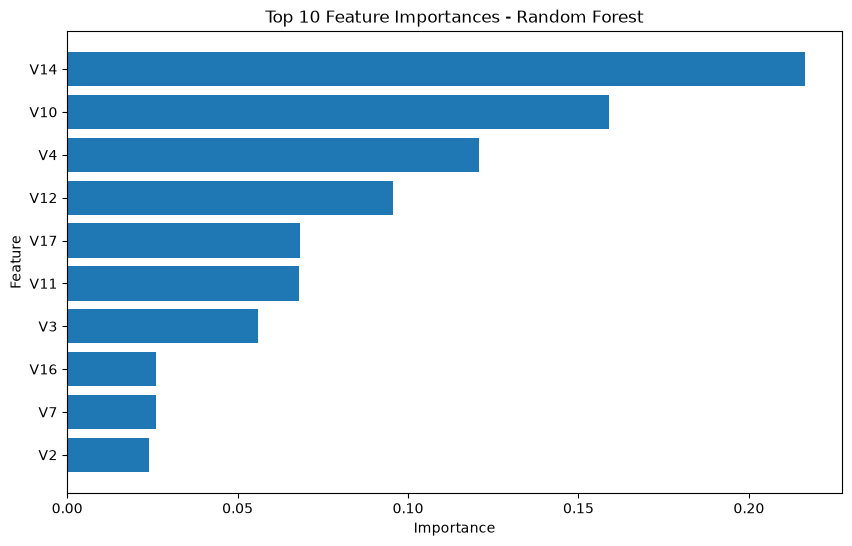

In [35]:
# Plot the top 10 Random Forest feature importances

top_features = rf_importance.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Feature Importance and Coefficient Analysis

Feature analysis was performed using both Logistic Regression coefficients and Random Forest feature importance.

For Logistic Regression, the features with the largest absolute coefficients included V17, V14, V12, V10, and V1. The sign of a coefficient indicates the direction of its relationship with the model’s predicted fraud probability, while the absolute value indicates the relative magnitude of the coefficient within the model.

For Random Forest, the most important features included V14, V10, V4, V12, V17, and V11. V14 had the highest feature importance at approximately 0.2165, followed by V10 at approximately 0.1591.

Several features, including V14, V10, V12, and V17, were important in both models. However, the V1–V28 variables are anonymized PCA-derived features, so their individual real-world meanings cannot be directly interpreted from the dataset.

### Scalability Considerations

The current fraud detection pipeline was developed and tested on a dataset containing 284,807 transactions. In a real-world environment processing approximately 1 million transactions per hour, additional infrastructure and optimization would be required.

A scalable fraud detection system could use a distributed data-processing framework such as Apache Spark to process large transaction volumes across multiple machines. A streaming platform such as Apache Kafka could be used to receive and process transactions continuously as they occur.

The trained machine learning model could be deployed as a real-time prediction service so that incoming transactions are scored for fraud as they are processed. Feature engineering and preprocessing would need to be optimized so that predictions can be generated with low latency.

The model and data-processing infrastructure could also be scaled horizontally by adding additional processing resources as transaction volume increases. Monitoring would be important to track model performance, changes in transaction patterns, and potential model drift over time.

Therefore, while the notebook demonstrates the fraud detection workflow on a static dataset, a production system handling 1 million transactions per hour would require distributed processing, real-time data ingestion, efficient model serving, monitoring, and infrastructure capable of handling high transaction throughput.

## Conclusion

This project developed a machine learning pipeline for detecting fraudulent credit card transactions in a highly imbalanced dataset. The workflow included data exploration, preprocessing, stratified train-test splitting, SMOTE-based handling of class imbalance, model training, evaluation, and feature importance analysis.

Two classification models were evaluated: Logistic Regression and Random Forest. Logistic Regression achieved a higher recall of 89.80%, meaning it identified a larger proportion of fraudulent transactions. However, its precision was relatively low at 13.06%, resulting in an F1-score of 22.80%.

Random Forest achieved an accuracy of 99.94%, precision of 83.51%, recall of 82.65%, and F1-score of 83.08%. Although its recall was slightly lower than Logistic Regression, it provided a much better balance between precision and recall and therefore performed better overall for this fraud detection task.

The results demonstrate that accuracy alone is not sufficient for evaluating fraud detection models, particularly when the dataset is highly imbalanced. Metrics such as precision, recall, F1-score, and AUC-ROC provide a more meaningful assessment of model performance.

Overall, Random Forest was selected as the stronger-performing model based on its balanced classification performance, while Logistic Regression remains useful when maximizing fraud detection recall is the primary objective.